In [1]:
import os

for i in  range(10):
    dir_text = !dir
    if any([".venv" in text for text in dir_text]):
        print(".venv encontrado")
        break
    else:
        print(f'{i} - os.chdir("..")')
        os.chdir("..")

    
%load_ext autoreload
%autoreload 2

0 - os.chdir("..")


1 - os.chdir("..")
2 - os.chdir("..")
.venv encontrado


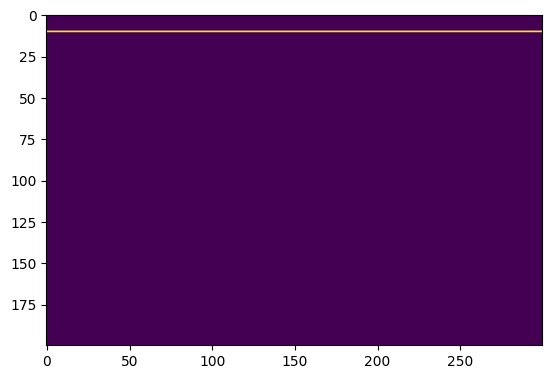

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Gerando imagem usando numpy
image = np.zeros((200, 300), dtype=np.uint8)

image[10] = 255

plt.imshow(image)


In [3]:
image

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], shape=(200, 300), dtype=uint8)

In [4]:

path = "/home/guilherme/py_projects/computer-vision/data/eu.jpeg"
image = cv2.imread(path)

In [5]:
image

In [6]:
path = "data/images/beija-flor.jpg"


In [7]:
def ajustar(val):
    alpha = cv2.getTrackbarPos('Contraste', 'Ajuste') / 100
    beta = cv2.getTrackbarPos('Brilho', 'Ajuste') - 100
    ajustada = cv2.convertScaleAbs(imagem, alpha=alpha, beta=beta)
    cv2.imshow('Ajuste', ajustada)

imagem = cv2.imread(path)
cv2.namedWindow('Ajuste')
cv2.createTrackbar('Contraste', 'Ajuste', 100, 300, ajustar)
cv2.createTrackbar('Brilho', 'Ajuste', 100, 200, ajustar)
ajustar(0)
cv2.waitKey(0)
cv2.destroyAllWindows()

error: OpenCV(4.12.0) D:\a\opencv-python\opencv-python\opencv\modules\highgui\src\window.cpp:868: error: (-215:Assertion failed) trackbar in function 'cv::getTrackbarPos'


🖱️ 1. Eventos de Mouse

Você pode capturar cliques, arrastar, desenhar formas, selecionar áreas… tudo com o mouse!

🔹 Ideal para criar ferramentas de anotação ou seleção de regiões

In [8]:
def desenhar(event, x, y, flags, param):
    if event == cv2.EVENT_LBUTTONDOWN:
        cv2.circle(imagem, (x, y), 10, (0, 255, 0), -1)
        cv2.imshow('Desenho', imagem)

imagem = cv2.imread(path)
cv2.imshow('Desenho', imagem)
cv2.setMouseCallback('Desenho', desenhar)
cv2.waitKey(0)
cv2.destroyAllWindows()

🎥 2. Captura de Vídeo em Tempo Real

Você pode usar a webcam para aplicar filtros ao vivo

🔹 Dá pra aplicar efeitos, detectar rostos, ou até fazer realidade aumentada


In [9]:
cap = cv2.VideoCapture(0, cv2.CAP_DSHOW)
while True:
    ret, frame = cap.read()
    if not ret:
        break
    cinza = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    cv2.imshow('Webcam - Cinza', cinza)
    if cv2.waitKey(1) & 0xFF == ord('q'):
        break
cap.release()
cv2.destroyAllWindows()

🧠 3. Detecção de Objetos com Haar Cascades

OpenCV tem modelos prontos para detectar rostos, olhos, sorrisos, etc.


🔹 Excelente para projetos de reconhecimento facial ou contagem de pessoas

In [ ]:
face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')
imagem = cv2.imread('pessoas.jpg')
gray = cv2.cvtColor(imagem, cv2.COLOR_BGR2GRAY)
faces = face_cascade.detectMultiScale(gray, 1.1, 4)

for (x, y, w, h) in faces:
    cv2.rectangle(imagem, (x, y), (x+w, y+h), (255, 0, 0), 2)

cv2.imshow('Detecção de Rostos', imagem)
cv2.waitKey(0)
cv2.destroyAllWindows()

🌀 4. Transformações Geométricas
Você pode rotacionar, redimensionar, aplicar perspectiva, etc.

🔹 Útil para pré-processamento de imagens em visão computacional

🧩 5. Segmentação com Contornos
Detectar formas, objetos e bordas com precisão.

🔹 Perfeito para reconhecimento de formas e objetos

In [ ]:
imagem = cv2.imread('formas.png')
gray = cv2.cvtColor(imagem, cv2.COLOR_BGR2GRAY)
_, thresh = cv2.threshold(gray, 127, 255, cv2.THRESH_BINARY)
contornos, _ = cv2.findContours(thresh, cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)
cv2.drawContours(imagem, contornos, -1, (0, 255, 0), 2)
cv2.imshow('Contornos', imagem)
cv2.waitKey(0)
cv2.destroyAllWindows()

In [10]:
def clique(event, x, y, flags, param):
    if event == cv2.EVENT_LBUTTONDOWN:
        if 50 < x < 150 and 50 < y < 100:
            print("Botão 1 clicado!")
        elif 200 < x < 300 and 50 < y < 100:
            print("Botão 2 clicado!")

imagem = 255 * np.ones((200, 400, 3), dtype=np.uint8)
cv2.rectangle(imagem, (50, 50), (150, 100), (0, 255, 0), -1)
cv2.putText(imagem, 'Botão 1', (60, 80), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 0, 0), 2)
cv2.rectangle(imagem, (200, 50), (300, 100), (0, 0, 255), -1)
cv2.putText(imagem, 'Botão 2', (210, 80), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 255, 255), 2)

cv2.imshow('Interface', imagem)
cv2.setMouseCallback('Interface', clique)
cv2.waitKey(0)
cv2.destroyAllWindows()

Botão 1 clicado!
Botão 2 clicado!
Botão 1 clicado!


In [12]:
import tkinter as tk
from PIL import Image, ImageTk
import cv2

def mostrar_imagem():
    img = cv2.imread(path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img_pil = Image.fromarray(img)
    img_tk = ImageTk.PhotoImage(img_pil)
    label.config(image=img_tk)
    label.image = img_tk

root = tk.Tk()
btn = tk.Button(root, text="Mostrar Imagem", command=mostrar_imagem)
btn.pack()
label = tk.Label(root)
label.pack()
root.mainloop()

In [14]:
while True:
    cv2.imshow('Imagem', imagem)
    tecla = cv2.waitKey(1) & 0xFF
    if tecla == ord('a'):
        print("Botão A pressionado")
    elif tecla == ord('b'):
        print("Botão B pressionado")
    elif tecla == 27:  # ESC
        break
cv2.destroyAllWindows()

Botão A pressionado
